<a href="https://colab.research.google.com/github/ayushi-0302/CNN-BiGRU-Attention-/blob/main/hybrid-sentiment-analysis-imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 733.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 136.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

VOCAB_SIZE = 10000
MAX_LEN = 256
EMBEDDING_DIM = 100
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# data
(X_train_raw, y_train), (X_val_raw, y_val) = imdb.load_data(num_words=VOCAB_SIZE)
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding="post")
X_val = pad_sequences(X_val_raw, maxlen=MAX_LEN, padding="post")

print("Data loaded:", X_train.shape, X_val.shape)

# attention layer
class AttentionLayer(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1],),
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):
        score = tf.tensordot(inputs, self.W, axes=1)
        weights = tf.nn.softmax(score, axis=1)
        weights = tf.expand_dims(weights, -1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context

# baseline GRU
def build_baseline_gru_model():
    inp = Input(shape=(MAX_LEN,), name="input_baseline")

    emb = Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(inp)

    # 0.5
    x = SpatialDropout1D(0.5)(emb)
    # 0.4
    x = GRU(128, recurrent_dropout=0.4)(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid", kernel_regularizer=l2(1e-4))(x)

    return Model(inp, out, name="Baseline_GRU_Reg")

# safe masking (embedding + token IDs)
class MaskingFixLayer(Layer):
    def call(self, inputs):
        emb, token_ids = inputs
        mask = tf.not_equal(token_ids, 0)
        mask = tf.cast(mask, tf.float32)
        mask = tf.expand_dims(mask, -1)
        return emb * mask

# hybrid
def build_hybrid_attn_model():
    inp = Input(shape=(MAX_LEN,), name="input_hybrid")

    emb = Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        mask_zero=False,
        name="embedding"
    )(inp)

    x = MaskingFixLayer()([emb, inp])
    # 0.5
    x = SpatialDropout1D(0.5)(x)

    # CNN branch
    c = Conv1D(128, 5, padding="same", activation="relu")(x)
    c = MaxPooling1D(2)(c)

    # biGRU branch (increased dropout/recurrent Dropout)
    r = Bidirectional(
        GRU(96, return_sequences=True, dropout=0.4, recurrent_dropout=0.4)
    )(x)
    r = MaxPooling1D(2)(r)

    merged = Concatenate()([c, r])

    att = AttentionLayer()(merged)
    att = Dropout(0.4)(att)
    out = Dense(1, activation="sigmoid", kernel_regularizer=l2(1e-4))(att)

    return Model(inp, out, name="Hybrid_CNN_BiGRU_Attn_Reg")

# callbacks
callbacks = [

    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1),

    EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)
]

# train baseline
baseline_model = build_baseline_gru_model()
baseline_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(5e-4),
    metrics=["accuracy"]
)

history_A = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=8,
    callbacks=callbacks,
    verbose=1
)

# train hybrid
hybrid_model = build_hybrid_attn_model()
hybrid_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(5e-4),
    metrics=["accuracy"]
)

history_B = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=8,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded: (25000, 256) (25000, 256)
Epoch 1/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 105s 524ms/step - accuracy: 0.5760 - loss: 0.6658 - val_accuracy: 0.7821 - val_loss: 0.4589 - learning_rate: 5.0000e-04
Epoch 2/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 100s 510ms/step - accuracy: 0.7871 - loss: 0.4629 - val_accuracy: 0.7979 - val_loss: 0.4304 - learning_rate: 5.0000e-04
Epoch 3/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 99s 504ms/step - accuracy: 0.8366 - loss: 0.3888 - val_accuracy: 0.8189 - val_loss: 0.3967 - learning_rate: 5.0000e-04
Epoch 4/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 99s 508ms/step - accuracy: 0.8609 - loss: 0.3398 - val_accuracy: 0.8280 - val_loss: 0.3838 - learning_rate: 5.0000e-04
Epoch 5/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 100s 508ms/step - accuracy: 0.8761 - loss: 0.3138 - val_accuracy: 0.8308 - val_loss: 0.3799 - learning_rate: 5.0000e-04
Epoch 6/8
196/196 ━━━━━━━━━━━━━━━━━━━━ 100s 508ms/step - accuracy: 0.8878 - loss: 0.2865 - val_accuracy: 0.8372 - val

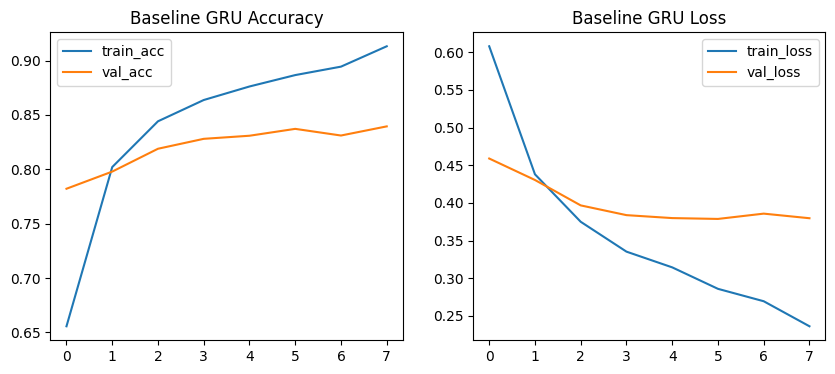

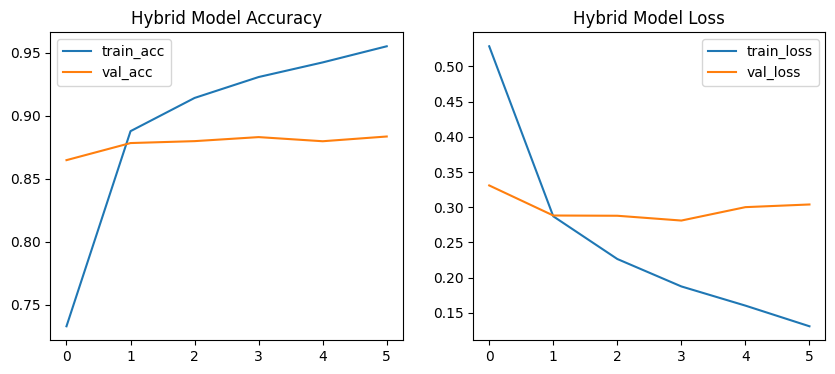

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(title + " Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

plot_history(history_A, "Baseline GRU")
plot_history(history_B, "Hybrid Model")

In [ ]:
print("Baseline evaluation:", baseline_model.evaluate(X_val, y_val))
print("Hybrid evaluation:", hybrid_model.evaluate(X_val, y_val))

for _ in range(5):
    i = np.random.randint(0, len(X_val))
    pred = hybrid_model.predict(X_val[i:i+1])[0][0]
    print("\nSAMPLE", i)
    print("True label:", y_val[i])
    print("Probability:", pred)
    print("Predicted:", "Positive" if pred > 0.5 else "Negative")

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8355 - loss: 0.3820
Baseline evaluation: [0.37873128056526184, 0.8371599912643433]
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.8845 - loss: 0.2775
Hybrid evaluation: [0.28107061982154846, 0.8828799724578857]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step

SAMPLE 23654
True label: 1
Probability: 0.6827219
Predicted: Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

SAMPLE 15795
True label: 0
Probability: 0.00730983
Predicted: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

SAMPLE 860
True label: 0
Probability: 0.00018276281
Predicted: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

SAMPLE 5390
True label: 0
Probability: 0.0033032354
Predicted: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

SAMPLE 21575
True label: 0
Probability: 0.10352188
Predicted: Negative
